## Aim 

In this notebook, some road characteristics per ward are created. This is done by reading in the entire Bangalore road network and then clipping it per ward. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [6]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [7]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [8]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [9]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [10]:
print(f'There are {df.shape[0]} wards in the dataset')

There are 369 wards in the dataset


Reading in the graph data (still in EPSG 4326):

In [11]:
G = ox.io.load_graphml(path_graphml)

In [12]:
G.graph["crs"]

'epsg:4326'

In [13]:
df.crs.to_epsg()

4326

The two coordinate systems need to be the same.

## Loop with road characteristics for each ward

Initialise the dataframe:

In [17]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'street_length', 'street_density', 'area'])
results

,ward_id,ward_name,Corporatio,street_length,street_density,area


In [18]:
df.crs.to_epsg()

4326

In [20]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    # print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]
    
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    G_clipped_proj = ox.projection.project_graph(G_clipped)

    ward_area = ox.projection.project_gdf(df_ward).union_all().area
    # print(ward_area)

    stats_area = ox.basic_stats(G_clipped_proj, area=ward_area)

    

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        stats_area['street_length_total'],
        stats_area['street_density_km'],
        ward_area
    ]

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [55:23<00:00,  9.01s/it]


In [21]:
results

,ward_id,ward_name,Corporatio,street_length,street_density,area
0,25,25 - Vinayaka Layout,West,67483.275675,26205.033174,2.575203e+06
1,2,2 - Aerocity,North,55739.693648,5433.217381,1.025906e+07
2,3,3 - Chowdeshwari ward,North,59321.900312,9225.355507,6.430310e+06
3,15,15 - Ramamurthy Nagara,East,21795.255226,27164.887476,8.023319e+05
4,58,58 - Nagashettyhalli,North,22246.721886,23284.035489,9.554496e+05
...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,21851.817891,17195.620644,1.270778e+06
365,57,57 - Cottonpete,Central,19834.032039,20755.222653,9.556164e+05
366,54,54 - Binnypete,Central,10885.028262,22814.336051,4.771135e+05
367,47,47 - IPD Salappa Ward,Central,11499.157962,23311.061274,4.932919e+05


In [22]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_all_roads_drive.csv"

results.to_csv(results_path)

In [23]:
print(f'The minimum density is {results["street_density"].min()}. metres per square kilometer')
print(f'The maximum density is {results["street_density"].max()}. metres per square kilometer')

The minimum density is 2974.0274091464794. metres per square kilometer
The maximum density is 42085.666300169876. metres per square kilometer


The ten wards with the highest density:

In [24]:
top10_highest = (
    results
    .sort_values(by='street_density', ascending=False)
    .head(10)
)
top10_highest

,ward_id,ward_name,Corporatio,street_length,street_density,area
56,53,53 - Rayapuram,Central,8829.650808,42085.666300,209801.853796
223,58,58 - Chickpete,Central,23741.924201,38631.403704,614575.757672
314,27,27 - K.G.Halli,North,15105.374550,37770.190041,399928.476229
22,35,35 - Kammanahalli,North,18986.115917,36998.590600,513157.815185
66,62,62 - Brundavana Nagara,North,24667.080938,36750.489483,671204.146798
39,45,45 - Kushal Nagar,North,10140.326026,36632.385080,276813.153263
26,51,51 - Old Guddadahalli,Central,7748.905815,36616.193774,211625.103977
298,56,56 - Gayathri Nagara,West,15834.021140,36126.402189,438294.991477
196,47,47 - Chandranagara,South,22064.961443,35965.444526,613504.482828
29,71,71 - Nele Maheshwaramma Temple Ward,North,21214.365793,35941.646673,590244.681486


The wards with the lowest density:

In [25]:
top10_lowest = (
    results
    .sort_values(by='street_density', ascending=True)
    .head(10)[['ward_id', 'ward_name', 'street_density']]
)
top10_lowest

,ward_id,ward_name,street_density
7,24,24 - Agaram,2974.027409
6,46,46 - Yamalur,3371.401054
205,27,27 - Vibhootipura,3784.538862
1,2,2 - Aerocity,5433.217381
208,49,49 - Shivanasamudra Ward,5930.818224
238,50,50 - Gunjur,6200.933042
45,39,39 - Hagaduru,6445.145516
251,48,48 - Panathur,6669.090428
130,31,31 - Kasavanahalli,7161.560122
250,30,30 - Belathur,7697.920986


Plot the ward with the highest and lowest street density, First merge this with the wards dataframe:

In [26]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,ward_id_y,Corporatio_y,street_length,street_density,area
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",25,West,67483.275675,26205.033174,2.575203e+06
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",2,North,55739.693648,5433.217381,1.025906e+07
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",3,North,59321.900312,9225.355507,6.430310e+06
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",15,East,21795.255226,27164.887476,8.023319e+05
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",58,North,22246.721886,23284.035489,9.554496e+05
...,...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",56,Central,21851.817891,17195.620644,1.270778e+06
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",57,Central,19834.032039,20755.222653,9.556164e+05
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",54,Central,10885.028262,22814.336051,4.771135e+05
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",47,Central,11499.157962,23311.061274,4.932919e+05


In [27]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'street_length', 'street_density', 'area']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,street_length,street_density,area
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",67483.275675,26205.033174,2.575203e+06
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",55739.693648,5433.217381,1.025906e+07
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",59321.900312,9225.355507,6.430310e+06
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",21795.255226,27164.887476,8.023319e+05
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",22246.721886,23284.035489,9.554496e+05
...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",21851.817891,17195.620644,1.270778e+06
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",19834.032039,20755.222653,9.556164e+05
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",10885.028262,22814.336051,4.771135e+05
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",11499.157962,23311.061274,4.932919e+05


In [28]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

Plot the network for the ward with the highest and lowest density next to each other:

In [29]:
df_highest = df_merged[df_merged.street_density == df_merged.street_density.max()]
df_highest

,ward_id,ward_name,Corporatio,geometry,street_length,street_density,area
56,53,53 - Rayapuram,Central,"POLYGON ((77.55458 12.96891, 77.55458 12.96891...",8829.650808,42085.6663,209801.853796


In [30]:
## Get the network for this ward and plot this:
ward_geometry_highest = df_highest.geometry.iloc[0]
ward_geometry_highest
    
G_clipped_highest = ox.truncate.truncate_graph_polygon(G, ward_geometry_highest)

## Just for checking purposes
G_clipped_proj_highest = ox.projection.project_graph(G_clipped_highest)

ward_area_highest = ox.projection.project_gdf(df_highest).union_all().area
print(ward_area_highest)

stats_area_highest = ox.basic_stats(G_clipped_proj_highest, area = ward_area_highest)
stats_area_highest

209801.85379589567


{'n': 176,
 'm': 469,
 'k_avg': 5.329545454545454,
 'edge_length_total': 17562.056765976464,
 'edge_length_avg': 37.44575003406496,
 'streets_per_node_avg': 2.903409090909091,
 'streets_per_node_counts': {0: 0, 1: 22, 2: 0, 3: 127, 4: 27},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.125,
  2: 0.0,
  3: 0.7215909090909091,
  4: 0.1534090909090909},
 'intersection_count': 154,
 'street_length_total': 8829.650808011094,
 'street_segment_count': 235,
 'street_length_avg': 37.57298216174934,
 'circuity_avg': 1.0123107778857816,
 'self_loop_proportion': 0.0,
 'node_density_km': 838.8867725221362,
 'intersection_density_km': 734.0259259568692,
 'edge_density_km': 83707.82454125307,
 'street_density_km': 42085.666300169876}

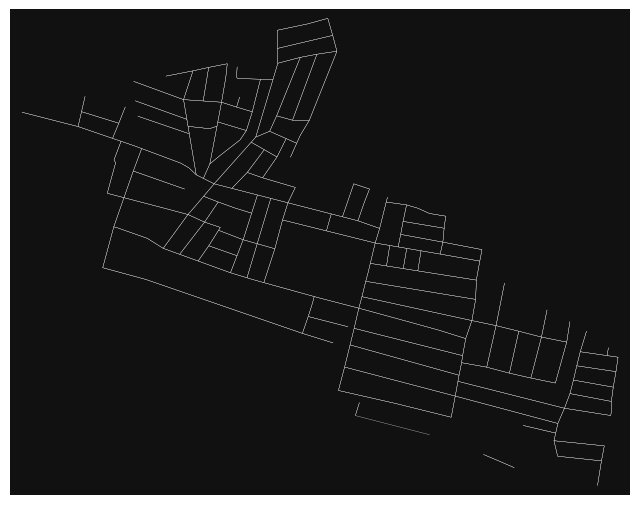

In [31]:
fig, ax = ox.plot_graph(G_clipped_proj_highest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [ ]:
## The second highest is Chickpete:


Figure for the entire Bangalore:

In [32]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'road_density_all_roads_bangalure_drive.png'

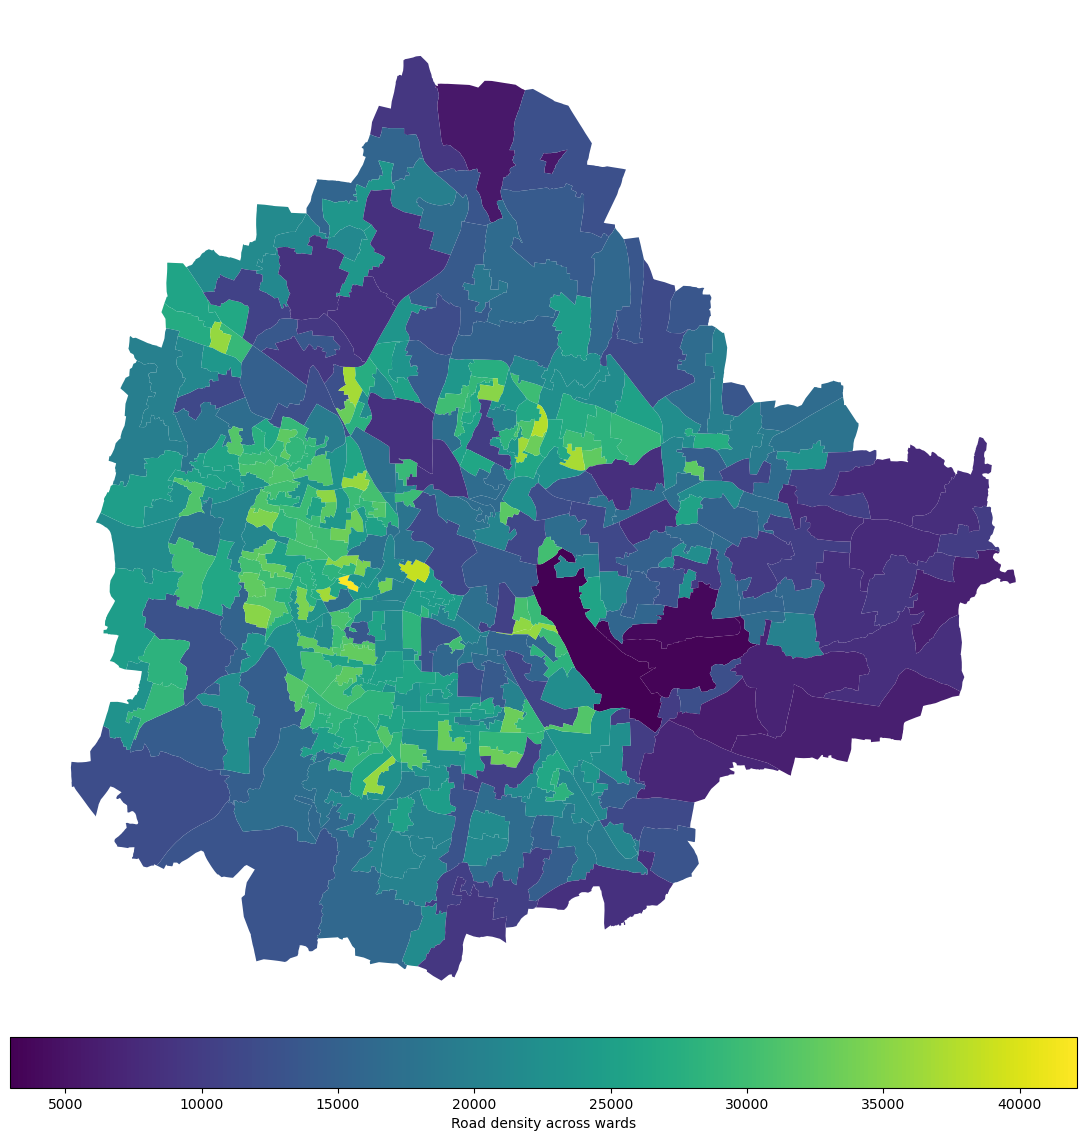

In [34]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="street_density",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "Road density across wards", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

## References

Boeing, G. (2025). Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

https://github.com/gboeing/osmnx-examples/tree/f6e821f598ccdb659999d008429cf867c69dcda1/notebooks